# 信贷违约预测分析

## Week 1：项目启动与数据探索

本周完成以下任务：

1. 检查Python环境和需要的库。
2. 使用Pandas读取贷款数据。
3. 查看数据形状、字段类型、缺失值和重复值。
4. 分析目标变量 `isDefault` 。
5. 查看主要数值、类别和日期字段。
6. 明确预测目标和后续评估指标。


### 交付物一：项目环境配置文档

#### 1. 开发环境

- 操作系统：macOS
- 环境管理工具：Anaconda
- Conda环境名称：credit-default
- Python版本：Python 3.12
- 开发工具：JupyterLab
- Notebook内核：Python (credit-default)

#### 2. 使用的主要Python库

- NumPy：用于数值计算
- Pandas：用于读取和处理数据
- Matplotlib：用于绘制基础图表
- Seaborn：用于数据可视化
- SciPy：用于统计分析
- Scikit-learn：用于后续的数据处理和模型训练

#### 3. 环境创建过程

首先使用Anaconda创建名为credit-default的独立环境，然后安装数据分析需要的Python库和JupyterLab。最后将该环境注册为Jupyter Notebook内核。

本项目已经能够正常导入相关库，并成功读取credit_data(1).csv数据文件。

### 交付物二：数据探索报告

#### 1. 导入库和检查环境

用Anaconda建立一个环境

In [12]:
# 导入数据分析和绘图需要的库。
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# 设置Seaborn绘图风格。
sns.set_theme(style="whitegrid")

# 显示当前环境。
print("Python路径：", sys.executable)
print("NumPy版本：", np.__version__)
print("Pandas版本：", pd.__version__)
print("scikit-learn版本：", sklearn.__version__)


Python路径： /opt/anaconda3/envs/credit-default/bin/python
NumPy版本： 1.26.4
Pandas版本： 2.2.3
scikit-learn版本： 1.5.2


#### 2. 读取数据

使用Pandas读取完整CSV。


In [2]:
# 原始CSV文件路径。
file_path = "/Users/xuxihe/Desktop/字节跳动/credit_data(1).csv"

# 读取完整数据。
df = pd.read_csv(file_path, low_memory=False)

print("数据形状：", df.shape)
print("记录数：", len(df))
print("字段数：", len(df.columns))

# 查看前5条记录。
display(df.head())


数据形状： (800000, 47)
记录数： 800000
字段数： 47


,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2 years,2,...,9.0,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0
1,1,18000.0,5,18.49,461.90,D,D2,219843.0,5 years,0,...,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8 years,0,...,0.0,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0
3,3,11000.0,3,7.26,340.96,A,A4,46854.0,10+ years,1,...,16.0,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0
4,4,3000.0,3,12.99,101.07,C,C2,54.0,NaN,1,...,4.0,9.0,10.0,15.0,7.0,12.0,0.0,0.0,0.0,4.0


#### 3. 数据结构和字段类型

In [14]:
# 查看字段名称、数据类型和非空数量。
df.info(show_counts=True)

# 汇总不同Pandas类型的字段数量。
type_summary = df.dtypes.astype(str).value_counts().to_frame("字段数量")
display(type_summary)

print("全部字段：")
print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 47 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  800000 non-null  int64  
 1   loanAmnt            800000 non-null  float64
 2   term                800000 non-null  int64  
 3   interestRate        800000 non-null  float64
 4   installment         800000 non-null  float64
 5   grade               800000 non-null  object 
 6   subGrade            800000 non-null  object 
 7   employmentTitle     799999 non-null  float64
 8   employmentLength    753201 non-null  object 
 9   homeOwnership       800000 non-null  int64  
 10  annualIncome        800000 non-null  float64
 11  verificationStatus  800000 non-null  int64  
 12  issueDate           800000 non-null  object 
 13  isDefault           800000 non-null  int64  
 14  purpose             800000 non-null  int64  
 15  postCode            799999 non-nul

,字段数量
float64,33
int64,9
object,5


全部字段：
['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade', 'subGrade', 'employmentTitle', 'employmentLength', 'homeOwnership', 'annualIncome', 'verificationStatus', 'issueDate', 'isDefault', 'purpose', 'postCode', 'regionCode', 'dti', 'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec', 'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc', 'initialListStatus', 'applicationType', 'earliesCreditLine', 'title', 'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14']


##### 主要字段理解

- `id`：贷款记录编号。
- `loanAmnt`：贷款金额。
- `term`：贷款期限。
- `interestRate`：贷款利率。
- `grade`、`subGrade`：贷款评级。
- `annualIncome`：年度收入。
- `dti`：债务收入比。
- `ficoRangeLow`、`ficoRangeHigh`：评分区间。
- `issueDate`：贷款发放月份。
- `earliesCreditLine`：最早信用记录月份。
- `isDefault`：是否违约，1为违约，0为没违约。
- `n0`至`n14`：匿名的特征，（还不知道是什么）

#### 4. 目标变量分析

预测目标是 `isDefault`。确认标签只有0和1、没有缺失，并统计总体的一个违约比例。


,记录数,占比
isDefault,,
0,640390,0.800488
1,159610,0.199513


未违约记录： 640390
违约记录： 159610
违约率： 19.95125%
目标变量缺失数： 0


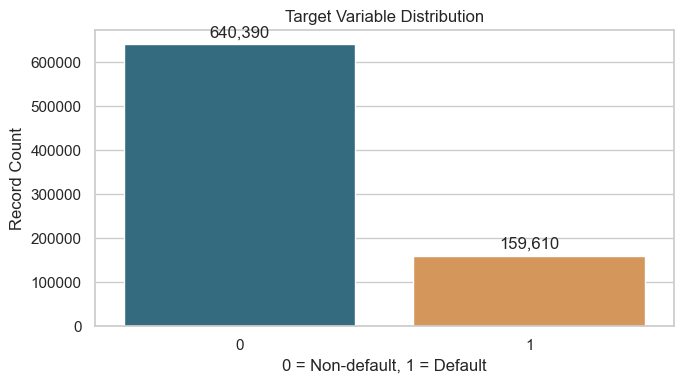

In [16]:
# 统计目标变量数量和比例。
target_count = df["isDefault"].value_counts().sort_index()
target_rate = df["isDefault"].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "记录数": target_count,
    "占比": target_rate
})
display(target_summary)

default_count = int((df["isDefault"] == 1).sum())
non_default_count = int((df["isDefault"] == 0).sum())
default_rate = float(df["isDefault"].mean())

print("未违约记录：", non_default_count)
print("违约记录：", default_count)
print("违约率：", f"{default_rate:.5%}")
print("目标变量缺失数：", df["isDefault"].isna().sum())

# 绘制目标变量数量分布。
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df,
    x="isDefault",
    hue="isDefault",
    palette=["#28718A", "#E89547"],
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
plt.title("Target Variable Distribution")
plt.xlabel("0 = Non-default, 1 = Default")
plt.ylabel("Record Count")
plt.tight_layout()
plt.show()


**结论：** 违约样本约占19.95%


#### 5. 缺失值检查

先统计了缺失值

存在缺失的字段数： 22
缺失单元格数： 667448
含缺失记录数： 113805
含缺失记录比例： 14.22563%


,缺失数量,缺失比例
n11,69752,0.087190
employmentLength,46799,0.058499
n8,40271,0.050339
n14,40270,0.050338
n13,40270,0.050338
n12,40270,0.050338
n9,40270,0.050338
n0,40270,0.050338
n1,40270,0.050338
n2,40270,0.050338


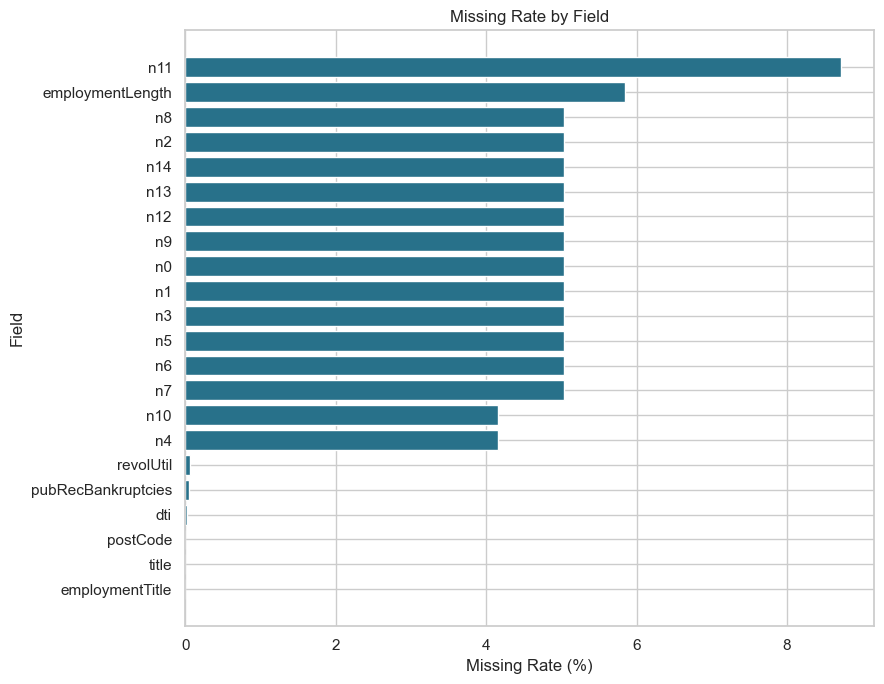

In [17]:
# 统计每个字段的缺失数量和缺失比例。
missing_summary = pd.DataFrame({
    "缺失数量": df.isna().sum(),
    "缺失比例": df.isna().mean()
})
missing_summary = missing_summary[
    missing_summary["缺失数量"] > 0
].sort_values("缺失数量", ascending=False)

missing_columns = int(df.isna().any().sum())
missing_cells = int(df.isna().sum().sum())
missing_rows = int(df.isna().any(axis=1).sum())

print("存在缺失的字段数：", missing_columns)
print("缺失单元格数：", missing_cells)
print("含缺失记录数：", missing_rows)
print("含缺失记录比例：", f"{missing_rows / len(df):.5%}")
display(missing_summary)

# 柱状图展示各字段缺失率
plot_data = missing_summary.sort_values("缺失比例")
plt.figure(figsize=(9, 7))
plt.barh(plot_data.index, plot_data["缺失比例"] * 100, color="#28718A")
plt.title("Missing Rate by Field")
plt.xlabel("Missing Rate (%)")
plt.ylabel("Field")
plt.tight_layout()
plt.show()


**结论：** 22个字段存在缺失，113,805条记录至少有一项缺失


#### 6. 业务目标与评估标准

### 预测目标

使用贷款申请和信用相关字段，预测一条贷款记录发生违约的概率。`isDefault=1` 为违约正类，`isDefault=0` 为未违约类。

### 后续数据划分

按照项目要求，后续使用训练集70%、验证集20%、测试集10%。
### 模型评估指标

- ROC-AUC：主要概率排序指标。
- Precision：预测违约中真实违约的比例。
- Recall：真实违约中被识别出来的比例。
- F1：综合Precision和Recall。
- Accuracy：保留报告，但需要与80.05%的多数类基线比较。

